### Problem Statement - Hybrid RAG System with Automated Evaluation

### Group ID: 46
### Group members

| Name           | Email                                       | Student ID   | Contribution |
|----------------|---------------------------------------------|--------------|--------------|
|  KUPPA GOWRI SANKAR | 2024aa05936@wilp.bits-pilani.ac.in          | 2024aa05936  | 100%         |
| JAIDEEP PALIT | 2024aa05319@wilp.bits-pilani.ac.in         | 2024aa05319 |100%|
| K ROMA PAI  | 2024aa05965@wilp.bits-pilani.ac.in         | 2024aa05965 |100%|
|MANJUNATHA K N |2024ab05252@wilp.bits-pilani.ac.in   |2024ab05252|100%|
|KARTHIK REDDY S |2024ab05330@wilp.bits-pilani.ac.in|2024ab05330|100%|

### Objective

Build a Hybrid Retrieval-Augmented Generation (RAG) system combining dense vector retrieval, sparse keyword retrieval (BM25), and Reciprocal Rank Fusion (RRF) to answer questions from 500 Wikipedia articles. Evaluate using an automated framework with 100 generated questions.


### Dataset Requirements:

Wikipedia URL Collection (500 URLs per group):

Fixed Set (200 URLs): Each group must first sample a unique set of 200 Wikipedia URLs (minimum 200 words per page) covering diverse topics. Store these in a JSON file (fixed_urls.json). No two groups should share the same 200 URLs. These URLs remain constant across all indexing operations.

Random Set (300 URLs): For each indexing run, randomly sample 300 additional Wikipedia URLs (minimum 200 words per page). These should change every time the system is rebuilt/indexed.

Total Corpus: 200 fixed + 300 random = 500 URLs. Extract, clean, and chunk the text (200-400 tokens with 50-token overlap). Store with metadata (URL, title, unique chunk IDs).

#### Import Libraries

In [ ]:
%pip install -q wikipedia sentence-transformers faiss-cpu rank-bm25 transformers torch nltk tqdm streamlit pandas gradio matplotlib seaborn

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 80.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 137.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 129.2 MB/s eta 0:00:00


In [ ]:
import os
import json
import random
import time
import uuid
import re
from tqdm import tqdm

import wikipedia
import nltk
from nltk.tokenize import word_tokenize

import numpy as np
import faiss

from sentence_transformers import SentenceTransformer
from rank_bm25 import BM25Okapi

from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
import torch
from collections import Counter
import random
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import re

# NLTK setup
nltk.download('punkt')
nltk.download('punkt_tab')


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

#### Configuration

In [ ]:
# Configuration
FIXED_URL_FILE = "fixed_urls.json"
RANDOM_URL_FILE = "random_urls_rebuilt.json"
MIN_WORDS = 200
NUM_FIXED = 200
NUM_RANDOM = 300
MAX_RETRIES = 10_000   # safety limit


#### Dataset creation

##### Fixed Set (200 URLs): Each group must first sample a unique set of 200 Wikipedia URLs (minimum 200 words per page) covering diverse topics. Store these in a JSON file (fixed_urls.json).

In [ ]:
def fetch_valid_wiki_page():
    try:
        page = wikipedia.page(wikipedia.random())
        text = page.content
        if len(text.split()) >= MIN_WORDS:
            return {
                "url": page.url,
                "title": page.title,
                "text": text
            }
    except:
        pass
    return None


In [ ]:
def load_or_create_fixed_urls():
    if os.path.exists(FIXED_URL_FILE):
        with open(FIXED_URL_FILE, "r") as f:
            fixed_pages = json.load(f)
        print(f"Loaded {len(fixed_pages)} fixed URLs from disk")
        return fixed_pages

    print("Fixed URLs not found. Creating fixed set...")
    fixed_pages = []
    seen_urls = set()

    attempts = 0
    while len(fixed_pages) < NUM_FIXED and attempts < MAX_RETRIES:
        page = fetch_valid_wiki_page()
        attempts += 1

        if page and page["url"] not in seen_urls:
            fixed_pages.append({
                "url": page["url"],
                "title": page["title"]
            })
            seen_urls.add(page["url"])

        if len(fixed_pages) % 25 == 0:
            print(f"Collected {len(fixed_pages)}/{NUM_FIXED} fixed URLs")

    if len(fixed_pages) < NUM_FIXED:
        raise RuntimeError("Could not collect enough fixed URLs")

    with open(FIXED_URL_FILE, "w") as f:
        json.dump(fixed_pages, f, indent=2)

    print("Fixed URLs saved to disk")
    return fixed_pages


In [ ]:
fixed_pages = load_or_create_fixed_urls()
fixed_url_set = set(p["url"] for p in fixed_pages)

print(f"Final fixed URL count: {len(fixed_url_set)}")

df = pd.DataFrame(fixed_pages)
df.head(5)


Fixed URLs not found. Creating fixed set...


/usr/local/lib/python3.12/dist-packages/wikipedia/wikipedia.py:389: GuessedAtParserWarning: No parser was explicitly specified, so I'm using the best available HTML parser for this system ("lxml"). This usually isn't a problem, but if you run this code on another system, or in a different virtual environment, it may use a different parser and behave differently.

The code that caused this warning is on line 389 of the file /usr/local/lib/python3.12/dist-packages/wikipedia/wikipedia.py. To get rid of this warning, pass the additional argument 'features="lxml"' to the BeautifulSoup constructor.

  lis = BeautifulSoup(html).find_all('li')


Collected 25/200 fixed URLs
Collected 50/200 fixed URLs
Collected 50/200 fixed URLs
Collected 50/200 fixed URLs
Collected 75/200 fixed URLs
Collected 100/200 fixed URLs
Collected 100/200 fixed URLs
Collected 125/200 fixed URLs
Collected 125/200 fixed URLs
Collected 150/200 fixed URLs
Collected 150/200 fixed URLs
Collected 175/200 fixed URLs
Collected 175/200 fixed URLs
Collected 200/200 fixed URLs
Fixed URLs saved to disk
Final fixed URL count: 200


,url,title
0,https://en.wikipedia.org/wiki/64th_Air_Refueli...,64th Air Refueling Squadron
1,https://en.wikipedia.org/wiki/Raymond_Lamont-B...,Raymond Lamont-Brown
2,https://en.wikipedia.org/wiki/Greenbank_High_S...,Greenbank High School
3,https://en.wikipedia.org/wiki/Norman_K._Gottwald,Norman K. Gottwald
4,https://en.wikipedia.org/wiki/Hip%C3%B3lito_Ru...,Hipólito Ruiz López


##### Random Set (300 URLs): For each indexing run, randomly sample 300 additional Wikipedia URLs (minimum 200 words per page).

In [ ]:
def create_random_urls(exclude_urls):
    random_pages = []
    seen_urls = set(exclude_urls)

    attempts = 0
    while len(random_pages) < NUM_RANDOM and attempts < MAX_RETRIES:
        page = fetch_valid_wiki_page()
        attempts += 1

        if page and page["url"] not in seen_urls:
            random_pages.append({
                "url": page["url"],
                "title": page["title"]
            })
            seen_urls.add(page["url"])

        if len(random_pages) % 25 == 0:
            print(f"Collected {len(random_pages)}/{NUM_RANDOM} random URLs")

    if len(random_pages) < NUM_RANDOM:
        raise RuntimeError("Could not collect enough random URLs")

    with open(RANDOM_URL_FILE, "w") as f:
        json.dump(random_pages, f, indent=2)

    print("Randon URLs(created during rebuild) saved to disk")
    return random_pages


In [ ]:
random_pages = create_random_urls(fixed_url_set)

/usr/local/lib/python3.12/dist-packages/wikipedia/wikipedia.py:389: GuessedAtParserWarning: No parser was explicitly specified, so I'm using the best available HTML parser for this system ("lxml"). This usually isn't a problem, but if you run this code on another system, or in a different virtual environment, it may use a different parser and behave differently.

The code that caused this warning is on line 389 of the file /usr/local/lib/python3.12/dist-packages/wikipedia/wikipedia.py. To get rid of this warning, pass the additional argument 'features="lxml"' to the BeautifulSoup constructor.

  lis = BeautifulSoup(html).find_all('li')


Collected 25/300 random URLs
Collected 50/300 random URLs
Collected 75/300 random URLs
Collected 100/300 random URLs
Collected 125/300 random URLs
Collected 125/300 random URLs
Collected 125/300 random URLs
Collected 125/300 random URLs
Collected 150/300 random URLs
Collected 150/300 random URLs
Collected 150/300 random URLs
Collected 175/300 random URLs
Collected 175/300 random URLs
Collected 200/300 random URLs
Collected 200/300 random URLs
Collected 225/300 random URLs
Collected 250/300 random URLs
Collected 275/300 random URLs
Collected 275/300 random URLs
Collected 275/300 random URLs
Collected 300/300 random URLs
Randon URLs(created during rebuild) saved to disk


In [ ]:
df = pd.DataFrame(random_pages)
df.head(5)

all_pages = fixed_pages + random_pages

assert len(all_pages) == 500
assert len(set(p["url"] for p in all_pages)) == 500

print("✅ Final corpus ready")
print(f"Fixed URLs : {len(fixed_pages)}")
print(f"Random URLs: {len(random_pages)}")

df = pd.DataFrame(all_pages)
df.head(5)

✅ Final corpus ready
Fixed URLs : 200
Random URLs: 300


,url,title
0,https://en.wikipedia.org/wiki/64th_Air_Refueli...,64th Air Refueling Squadron
1,https://en.wikipedia.org/wiki/Raymond_Lamont-B...,Raymond Lamont-Brown
2,https://en.wikipedia.org/wiki/Greenbank_High_S...,Greenbank High School
3,https://en.wikipedia.org/wiki/Norman_K._Gottwald,Norman K. Gottwald
4,https://en.wikipedia.org/wiki/Hip%C3%B3lito_Ru...,Hipólito Ruiz López


### Preprocessing

####  Extract, clean, and chunk the text (200-400 tokens with 50-token overlap). Store with metadata (URL, title, unique chunk IDs).

In [ ]:
# Text cleaner
def clean_text(text):
    text = re.sub(r'\n+', ' ', text)
    text = re.sub(r'\s+', ' ', text)
    return text.strip()

In [ ]:
documents = []

for page_info in tqdm(all_pages):
    try:
        page = wikipedia.page(page_info["title"])
        text = clean_text(page.content)

        if len(text.split()) < MIN_WORDS:
            continue  # extra safety

        documents.append({
            "url": page.url,
            "title": page.title,
            "text": text
        })
    except:
        continue

print(f"Documents extracted: {len(documents)}")

 19%|█▊        | 93/500 [00:57<04:30,  1.50it/s]/usr/local/lib/python3.12/dist-packages/wikipedia/wikipedia.py:389: GuessedAtParserWarning: No parser was explicitly specified, so I'm using the best available HTML parser for this system ("lxml"). This usually isn't a problem, but if you run this code on another system, or in a different virtual environment, it may use a different parser and behave differently.

The code that caused this warning is on line 389 of the file /usr/local/lib/python3.12/dist-packages/wikipedia/wikipedia.py. To get rid of this warning, pass the additional argument 'features="lxml"' to the BeautifulSoup constructor.

  lis = BeautifulSoup(html).find_all('li')
100%|██████████| 500/500 [05:18<00:00,  1.57it/s]

Documents extracted: 491


In [ ]:
with open("documents.json", "w") as f:
    json.dump(documents, f, indent=2)

#### Chunking function

In [ ]:
def chunk_text(text, min_tokens=200, max_tokens=400, overlap=50):
    tokens = word_tokenize(text)
    chunks = []

    start = 0
    while start < len(tokens):
        end = min(start + max_tokens, len(tokens))
        chunk = tokens[start:end]
        if len(chunk) >= min_tokens:
            chunks.append(" ".join(chunk))
        start += max_tokens - overlap

    return chunks


####  Create chunks with metadata

In [ ]:
chunks = []

for doc in tqdm(documents):
    doc_chunks = chunk_text(doc["text"])
    for idx, chunk in enumerate(doc_chunks):
        chunks.append({
            "chunk_id": str(uuid.uuid4()),
            "title": doc["title"],
            "url": doc["url"],
            "text": chunk,
            "chunk_index": idx
        })

print(f"Total chunks created: {len(chunks)}")

100%|██████████| 491/491 [00:02<00:00, 165.48it/s]

Total chunks created: 1554


In [ ]:
with open("chunks.json", "w") as f:
    json.dump(chunks, f, indent=2)

In [ ]:
df = pd.DataFrame(chunks)
df.head(5)

,chunk_id,title,url,text,chunk_index
0,69f4be34-77ba-4ef8-b438-6da2a1b9e543,64th Air Refueling Squadron,https://en.wikipedia.org/wiki/64th_Air_Refueli...,The 64th Air Refueling Squadron is a United St...,0
1,1b5f5bde-f824-4c56-afb5-33f5e496eebe,64th Air Refueling Squadron,https://en.wikipedia.org/wiki/64th_Air_Refueli...,", and equipment of the 700th Troop Carrier Squ...",1
2,45b5baec-86e9-456d-8f88-4b4befa98355,64th Air Refueling Squadron,https://en.wikipedia.org/wiki/64th_Air_Refueli...,Ordered to active service on 28 October 1962 R...,2
3,bacc2d04-606c-45fe-979f-7e3fa28e6baf,Raymond Lamont-Brown,https://en.wikipedia.org/wiki/Raymond_Lamont-B...,Raymond Lamont-Brown ( born 1939 ) is a Scotti...,0
4,534b5db2-48ab-49bf-b4c1-a149a3ee43da,Greenbank High School,https://en.wikipedia.org/wiki/Greenbank_High_S...,Greenbank High School is an all-girls secondar...,0


#### Exploratory Data Analysis

In [ ]:
from collections import Counter

# 1. Count how many times each URL appears
url_counts = Counter(chunk["url"] for chunk in chunks)

# 2. Extract the counts into a list
counts = list(url_counts.values())

# 3. Calculate metrics
total_unique_urls = len(url_counts)
min_chunks = min(counts) if counts else 0
max_chunks = max(counts) if counts else 0
avg_chunks = sum(counts) / len(counts) if counts else 0

# Print results
print(f"Min chunks per URL: {min_chunks}")
print(f"Max chunks per URL: {max_chunks}")
print(f"Avg chunks per URL: {avg_chunks:.2f}")

Min chunks per URL: 1
Max chunks per URL: 29
Avg chunks per URL: 3.16


In [ ]:

sample_chuncks = random.sample(chunks, 5)

for i, chunk in enumerate(sample_chuncks, 1):
    print("=" * 80)
    print(f"Sample Document {i}")
    print(f"Chunk ID     : {chunk['chunk_id']}")
    print(f"URL          : {chunk['url']}")
    print(f"Word Count   : {len(chunk['text'].split())}")
    print("-" * 80)
    print(chunk['text'][:400])  # print only first 800 chars
    print("...")

Sample Document 1
Chunk ID     : 1cfad79e-7d97-45a9-a7b9-83d6d0774bcd
URL          : https://en.wikipedia.org/wiki/Joe_Walton
Word Count   : 400
--------------------------------------------------------------------------------
Joseph Frank Walton ( December 15 , 1935 – August 15 , 2021 ) was an American professional football player and coach who retired after 20 years as the head coach and creator of the football program at Robert Morris University . Walton played eight seasons in the National Football League ( NFL ) as a pass catching tight end for the Redskins and Giants . He served as head coach of the New York Jets 
...
Sample Document 2
Chunk ID     : 65889d83-21f6-479c-83d9-d792aee890ef
URL          : https://en.wikipedia.org/wiki/90th_Minnesota_Legislature
Word Count   : 400
--------------------------------------------------------------------------------
The Ninetieth Minnesota Legislature was the legislature of the U.S. state of Minnesota from January 3 , 2017 to January 7 , 201

### Data Overview ###
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1554 entries, 0 to 1553
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   chunk_id     1554 non-null   object
 1   title        1554 non-null   object
 2   url          1554 non-null   object
 3   text         1554 non-null   object
 4   chunk_index  1554 non-null   int64 
dtypes: int64(1), object(4)
memory usage: 60.8+ KB
None

### Missing Values ###
chunk_id       0
title          0
url            0
text           0
chunk_index    0
dtype: int64


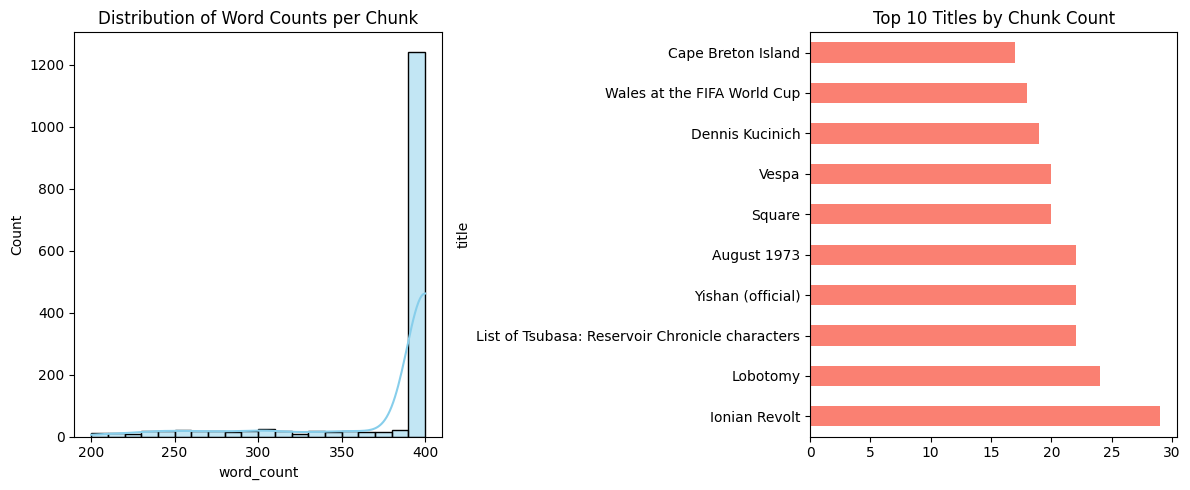


Total Chunks: 1554
Unique Titles: 491
Duplicate Chunks (by ID): 0

### Chunk Index Statistics ###
count    1554.000000
mean        3.303089
std         4.559279
min         0.000000
25%         0.000000
50%         1.000000
75%         4.000000
max        28.000000
Name: chunk_index, dtype: float64


In [ ]:
# --- BASIC INSPECTION ---
print("### Data Overview ###")
print(df.info())
print("\n### Missing Values ###")
print(df.isnull().sum())

# --- TEXT SPECIFIC ANALYSIS ---
# Calculate the length of the text and word counts
df['char_count'] = df['text'].str.len()
df['word_count'] = df['text'].apply(lambda x: len(str(x).split()))

# --- EDA VISUALIZATIONS ---
plt.figure(figsize=(12, 5))

# Plot 1: Distribution of word counts (Helps find outliers or empty chunks)
plt.subplot(1, 2, 1)
sns.histplot(df['word_count'], bins=20, kde=True, color='skyblue')
plt.title('Distribution of Word Counts per Chunk')

# Plot 2: Chunks per Title (Top 10 most frequent titles)
plt.subplot(1, 2, 2)
df['title'].value_counts().head(10).plot(kind='barh', color='salmon')
plt.title('Top 10 Titles by Chunk Count')

plt.tight_layout()
plt.show()

# --- DUPLICATE & REPETITION CHECK ---
print(f"\nTotal Chunks: {len(df)}")
print(f"Unique Titles: {df['title'].nunique()}")
print(f"Duplicate Chunks (by ID): {df.duplicated('chunk_id').sum()}")

# Statistics for chunk indices (checks if any pages have huge gaps or overlaps)
print("\n### Chunk Index Statistics ###")
print(df['chunk_index'].describe())

/tmp/ipython-input-1492848598.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='title', y='word_count', data=df, palette='Set2')
/tmp/ipython-input-1492848598.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=bg_counts, y=bg_labels, palette='viridis')
/tmp/ipython-input-1492848598.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(x='title', y='chunk_index', data=df, jitter=True, size=8, palette='autumn')


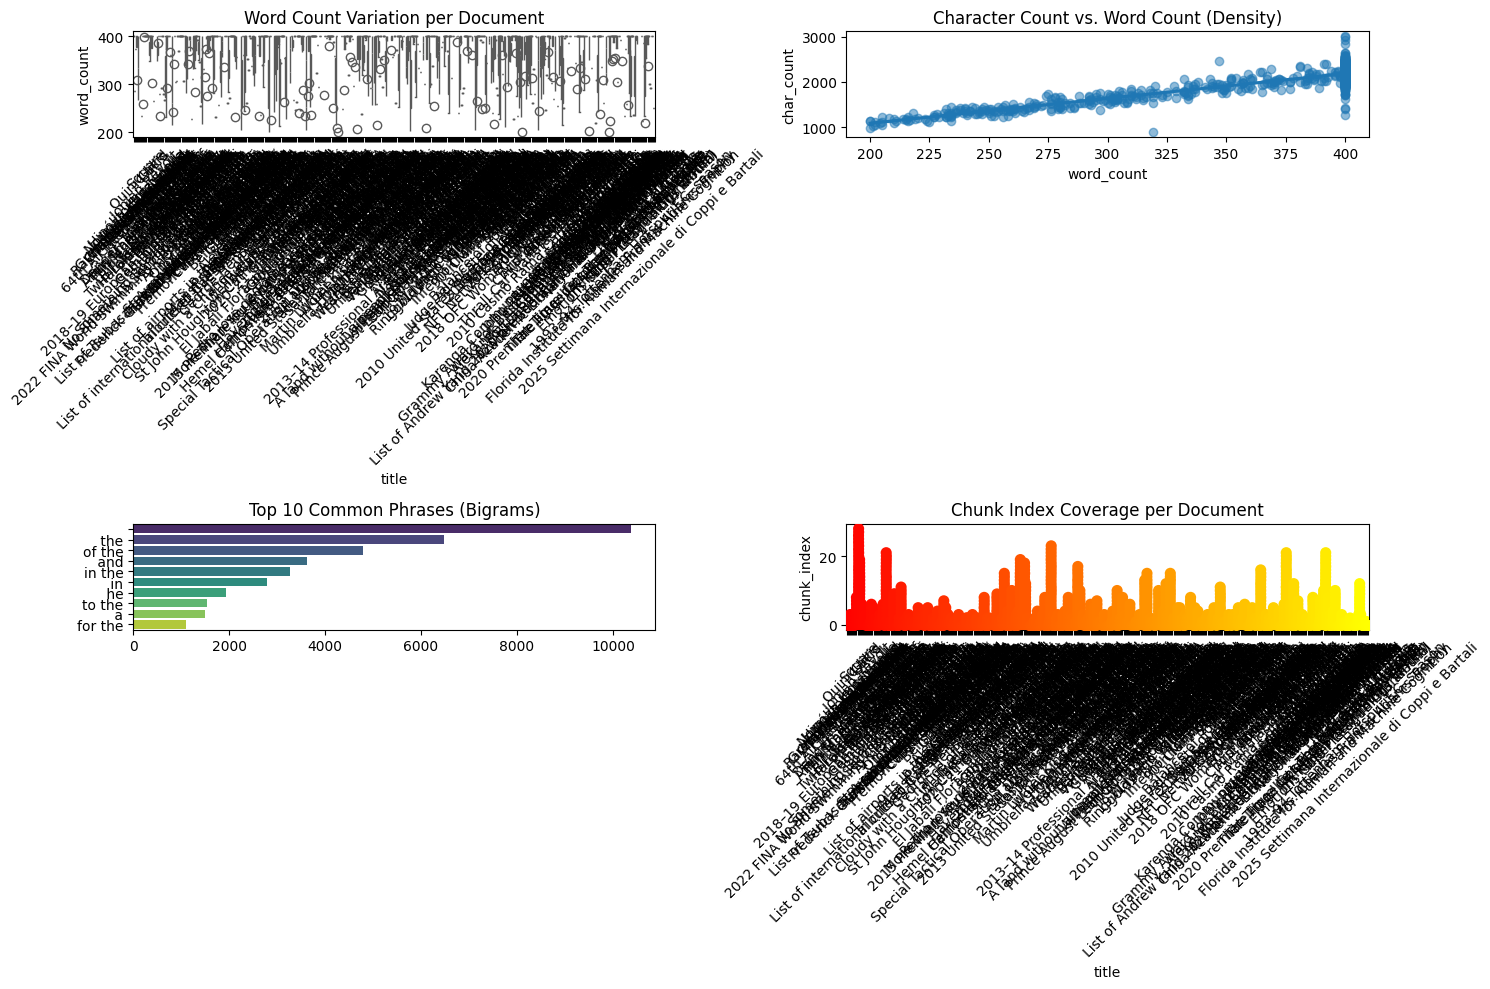

In [ ]:
# Assuming 'df' is your DataFrame from the previous step
df['char_count'] = df['text'].str.len()
df['word_count'] = df['text'].apply(lambda x: len(str(x).split()))

# Setup the plotting area
plt.figure(figsize=(15, 10))

# --- CHART 1: Word Count Box Plot (By Title) ---
plt.subplot(2, 2, 1)
sns.boxplot(x='title', y='word_count', data=df, palette='Set2')
plt.title('Word Count Variation per Document')
plt.xticks(rotation=45)

# --- CHART 2: Char vs Word Scatter Plot ---
plt.subplot(2, 2, 2)
sns.regplot(x='word_count', y='char_count', data=df, scatter_kws={'alpha':0.5})
plt.title('Character Count vs. Word Count (Density)')

# --- CHART 3: Top 10 Bigrams ---
plt.subplot(2, 2, 3)
def get_bigrams(text_series):
    words = " ".join(text_series).lower().split()
    words = [re.sub(r'[^\w\s]', '', w) for w in words] # Clean punctuation
    bigrams = zip(words, words[1:])
    return Counter(bigrams).most_common(10)

common_bg = get_bigrams(df['text'])
bg_labels = [f"{b[0][0]} {b[0][1]}" for b in common_bg]
bg_counts = [b[1] for b in common_bg]
sns.barplot(x=bg_counts, y=bg_labels, palette='viridis')
plt.title('Top 10 Common Phrases (Bigrams)')

# --- CHART 4: Chunk Index Coverage ---
plt.subplot(2, 2, 4)
sns.stripplot(x='title', y='chunk_index', data=df, jitter=True, size=8, palette='autumn')
plt.title('Chunk Index Coverage per Document')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### Part 1: Hybrid RAG System

#### 1.1 Dense Vector Retrieval

##### Use a sentence embedding model (e.g., all-MiniLM-L6-v2) to embed chunks

In [ ]:
# Load embedding model
embed_model = SentenceTransformer("all-MiniLM-L6-v2")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

##### Generate embeddings

In [ ]:
# Generate embeddings
chunk_texts = [c["text"] for c in chunks]
embeddings = embed_model.encode(chunk_texts, show_progress_bar=True)

Batches:   0%|          | 0/49 [00:00<?, ?it/s]

##### Build a vector index (FAISS)

In [ ]:
# Build FAISS index
dimension = embeddings.shape[1]
index = faiss.IndexFlatIP(dimension)

faiss.normalize_L2(embeddings)
index.add(embeddings)

print("FAISS index built")

faiss.write_index(index, "faiss_index.index")


FAISS index built


##### Vector Space Visualization (PCA/t-SNE)

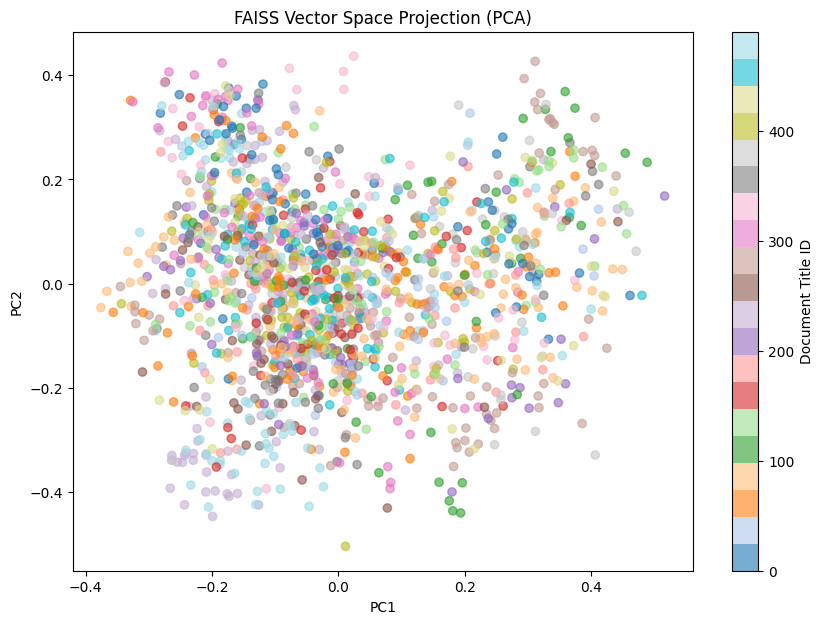

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# 1. Extract embeddings (assuming you have your 'embeddings' numpy array)
# If you only have the index, you'd need to have stored the vectors.
# Let's assume 'embeddings' is your (N, dimensions) array.

# 2. Reduce dimensions to 2D using PCA (Fast) or t-SNE (Better clusters)
pca = PCA(n_components=2)
reduced_embeddings = pca.fit_transform(embeddings)

# 3. Plot
plt.figure(figsize=(10, 7))
scatter = plt.scatter(reduced_embeddings[:, 0], reduced_embeddings[:, 1],
                      c=df['title'].astype('category').cat.codes,
                      cmap='tab20', alpha=0.6)

plt.colorbar(scatter, label='Document Title ID')
plt.title('FAISS Vector Space Projection (PCA)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.show()

##### Distance Distribution Histogram

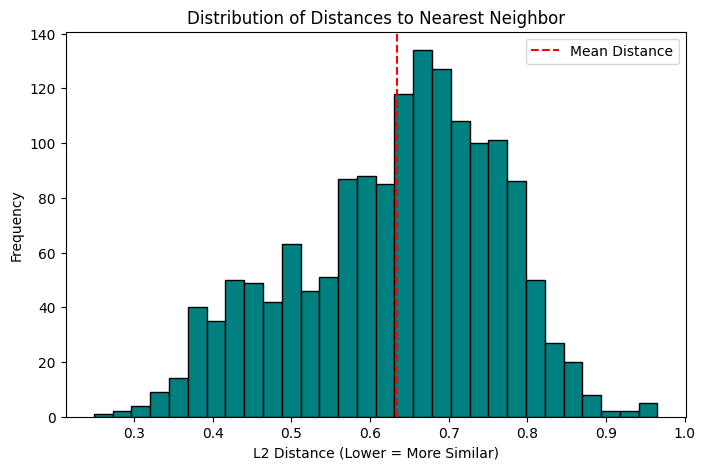

In [ ]:
# 1. Search the index against itself (find nearest neighbors for each chunk)
# k=2 because the 1st result will be the chunk itself (distance 0)
D, I = index.search(embeddings, k=2)

# 2. Get the distances to the 2nd nearest neighbor (the closest 'other' chunk)
neighbor_distances = D[:, 1]

# 3. Plot the distribution
plt.figure(figsize=(8, 5))
plt.hist(neighbor_distances, bins=30, color='teal', edgecolor='black')
plt.axvline(np.mean(neighbor_distances), color='red', linestyle='dashed', label='Mean Distance')
plt.title('Distribution of Distances to Nearest Neighbor')
plt.xlabel('L2 Distance (Lower = More Similar)')
plt.ylabel('Frequency')
plt.legend()
plt.show()

##### Retrieve top-K chunks via cosine similarity.

In [ ]:
# Dense retrieval
def dense_retrieve(query, top_k=10):
    q_emb = embed_model.encode([query])
    faiss.normalize_L2(q_emb)
    scores, indices = index.search(q_emb, top_k)

    results = []
    for rank, idx in enumerate(indices[0]):
        results.append({
            "chunk": chunks[idx],
            "score": float(scores[0][rank]),
            "rank": rank + 1
        })
    return results

In [ ]:
res=dense_retrieve("Where was Ellis born?")

df = pd.DataFrame(res)

df

,chunk,score,rank
0,{'chunk_id': '362b369f-d2dc-49cd-a188-ca23f042...,0.346455,1
1,{'chunk_id': '529ee061-5583-4173-a255-df82c904...,0.321464,2
2,{'chunk_id': 'ef3319fb-19fb-402c-857b-25dbe3ec...,0.299719,3
3,{'chunk_id': 'b8216ede-d63f-474c-8cec-2053a95c...,0.293824,4
4,{'chunk_id': '90cc2a36-0a11-46df-8cab-2d284bc5...,0.290782,5
5,{'chunk_id': '22337a2d-db3d-4875-bf58-6c05ef04...,0.288993,6
6,{'chunk_id': '02940a95-80e9-47c7-b4d2-491062ab...,0.286754,7
7,{'chunk_id': 'b36d6d41-73a5-4907-a918-dfdfae0e...,0.286160,8
8,{'chunk_id': '96c1f536-be86-4aa2-954d-fd76c015...,0.284629,9
9,{'chunk_id': '3a0addd2-3eb7-4718-9cf7-98f14e53...,0.284429,10


#### 1.2 Sparse Keyword Retrieval

##### Implement BM25 algorithm for keyword-based retrieval.

In [ ]:
# Prepare BM25 corpus
tokenized_corpus = [word_tokenize(c["text"].lower()) for c in chunks]
bm25 = BM25Okapi(tokenized_corpus)

In [ ]:
import pickle

# Save the BM25 object to a local file
with open("bm25_index.pkl", "wb") as f:
    pickle.dump(bm25, f)

##### BM25 Analysis Plot

/tmp/ipython-input-366026306.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=idf_df.head(15), x='idf', y='word', palette='magma')


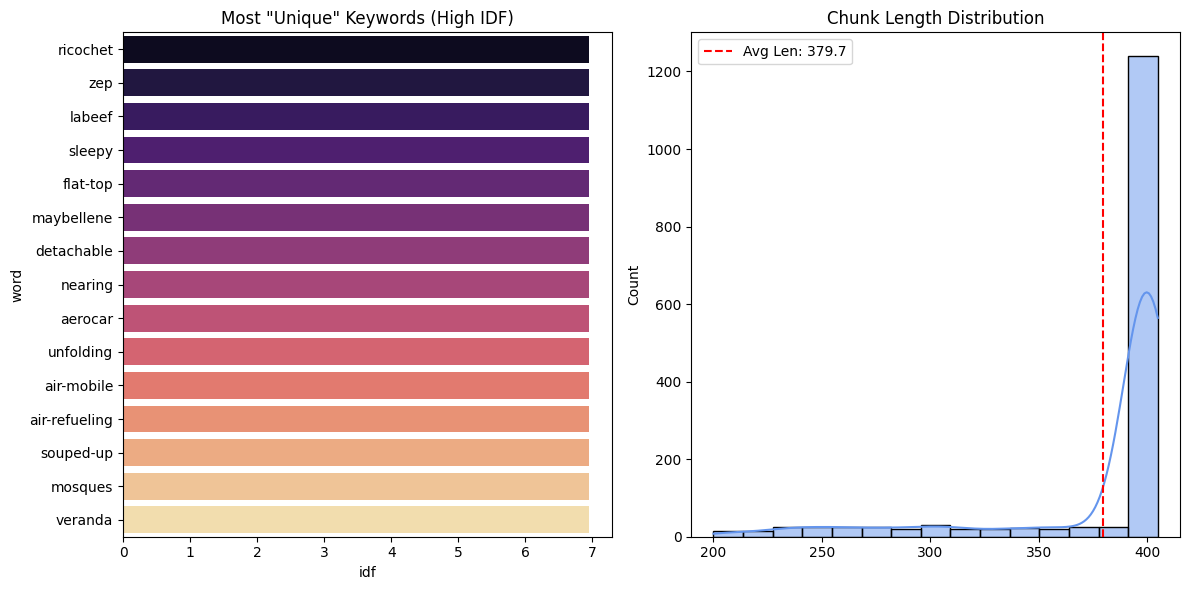

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Extracting stats from the BM25 object
# bm25.doc_len is a list of lengths of all documents in the corpus
doc_lengths = bm25.doc_len
avg_dl = bm25.avgdl

# Extracting IDF data
idf_data = [{'word': word, 'idf': score} for word, score in bm25.idf.items()]
idf_df = pd.DataFrame(idf_data).sort_values(by='idf', ascending=False)

plt.figure(figsize=(12, 6))

# Chart 1: Top 15 Highest IDF Words
plt.subplot(1, 2, 1)
sns.barplot(data=idf_df.head(15), x='idf', y='word', palette='magma')
plt.title('Most "Unique" Keywords (High IDF)')

# Chart 2: Document Length Distribution
plt.subplot(1, 2, 2)
sns.histplot(doc_lengths, bins=15, kde=True, color='cornflowerblue')
plt.axvline(avg_dl, color='red', linestyle='--', label=f'Avg Len: {avg_dl:.1f}')
plt.title('Chunk Length Distribution')
plt.legend()

plt.tight_layout()
plt.show()

##### Build index over chunks and retrieve top-K results.

In [ ]:
# BM25 retrieval
def bm25_retrieve(query, top_k=10):
    tokenized_query = word_tokenize(query.lower())
    scores = bm25.get_scores(tokenized_query)
    top_indices = np.argsort(scores)[::-1][:top_k]

    results = []
    for rank, idx in enumerate(top_indices):
        results.append({
            "chunk": chunks[idx],
            "score": scores[idx],
            "rank": rank + 1
        })
    return results

In [ ]:
bm25_res=bm25_retrieve("Where was Ellis born?")

df = pd.DataFrame(bm25_res)

df

,chunk,score,rank
0,{'chunk_id': 'e361cc6f-0177-4453-8fd0-ddff81be...,11.904436,1
1,{'chunk_id': '90cc2a36-0a11-46df-8cab-2d284bc5...,11.716796,2
2,{'chunk_id': 'bacc2d04-606c-45fe-979f-7e3fa28e...,11.380034,3
3,{'chunk_id': 'c7031a21-ec90-41d4-a126-f77b89c0...,10.181456,4
4,{'chunk_id': 'b771f54e-688b-418d-a8a5-5f7ca520...,9.935011,5
5,{'chunk_id': 'fd6173a9-0ca3-4ff8-8fe1-f76a4abe...,9.686791,6
6,{'chunk_id': '11c0f070-f27d-462e-9775-f1abaefb...,9.558581,7
7,{'chunk_id': '02940a95-80e9-47c7-b4d2-491062ab...,8.979491,8
8,{'chunk_id': 'f2d828e6-caa6-4d43-b16c-749ff3e1...,8.396874,9
9,{'chunk_id': 'ba82c218-d4d0-4905-8140-47cd6686...,8.375093,10


#### 1.3 Reciprocal Rank Fusion (RRF)

In [ ]:
# RRF implementation
def reciprocal_rank_fusion(dense_results, sparse_results, k=60, top_n=5):
    scores = {}

    for res in dense_results:
        cid = res["chunk"]["chunk_id"]
        scores.setdefault(cid, 0)
        scores[cid] += 1 / (k + res["rank"])

    for res in sparse_results:
        cid = res["chunk"]["chunk_id"]
        scores.setdefault(cid, 0)
        scores[cid] += 1 / (k + res["rank"])

    ranked = sorted(scores.items(), key=lambda x: x[1], reverse=True)

    final_chunks = []
    for cid, score in ranked[:top_n]:
        chunk = next(c for c in chunks if c["chunk_id"] == cid)
        final_chunks.append({
            "chunk": chunk,
            "rrf_score": score
        })

    return final_chunks


In [ ]:
rrf_res=reciprocal_rank_fusion(dense_results=res,sparse_results=bm25_res,top_n=10)
df = pd.DataFrame(rrf_res)

df

,chunk,rrf_score
0,{'chunk_id': '90cc2a36-0a11-46df-8cab-2d284bc5...,0.031514
1,{'chunk_id': '02940a95-80e9-47c7-b4d2-491062ab...,0.029631
2,{'chunk_id': '362b369f-d2dc-49cd-a188-ca23f042...,0.016393
3,{'chunk_id': 'e361cc6f-0177-4453-8fd0-ddff81be...,0.016393
4,{'chunk_id': '529ee061-5583-4173-a255-df82c904...,0.016129
5,{'chunk_id': 'ef3319fb-19fb-402c-857b-25dbe3ec...,0.015873
6,{'chunk_id': 'bacc2d04-606c-45fe-979f-7e3fa28e...,0.015873
7,{'chunk_id': 'b8216ede-d63f-474c-8cec-2053a95c...,0.015625
8,{'chunk_id': 'c7031a21-ec90-41d4-a126-f77b89c0...,0.015625
9,{'chunk_id': 'b771f54e-688b-418d-a8a5-5f7ca520...,0.015385


#### 1.4 Response Generation

##### Use an open-source LLM (e.g., DistilGPT2, Flan-T5-base, Llama-2-7B).

In [ ]:
#Load LLM
tokenizer = AutoTokenizer.from_pretrained("google/flan-t5-base")
model = AutoModelForSeq2SeqLM.from_pretrained("google/flan-t5-base")

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/990M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/282 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

In [ ]:
def generate_answer(query, context_chunks):
    context = " ".join([c["chunk"]["text"] for c in context_chunks])

    prompt = f"""
Answer the question using the context below.

Context:
{context}

Question:
{query}

Answer:
"""

    inputs = tokenizer(prompt, return_tensors="pt", truncation=True, max_length=1024)
    outputs = model.generate(**inputs, max_new_tokens=200)

    return tokenizer.decode(outputs[0], skip_special_tokens=True)

In [ ]:
def build_prompt(query, context_chunks):
    context = "\n\n".join(
        [f"[Chunk {i+1}]\n{c['chunk']['text']}"
         for i, c in enumerate(context_chunks)]
    )

    prompt = f"""

You are a question-answering system.

Use ONLY the information provided in the context below.
The context is ordered by relevance.

IMPORTANT RULES:
- The answer may appear in ONLY ONE chunk.
- If ANY chunk contains sufficient information, answer using that chunk alone.
- Ignore other chunks if they are not needed.
- Earlier chunks are MORE relevant than later chunks.
- If the answer cannot be reasonably inferred from the context, say:
"Answer not found in the provided context."

Question:
{query}



Context:
{context}



Answer:
""".strip()

    return prompt


In [ ]:
def generate_answer_from_prompt(prompt, debug=False):
    if debug:
        print("==== FINAL PROMPT SENT TO LLM ====")
        print(prompt)
        print("================================")

    inputs = tokenizer(
        prompt,
        return_tensors="pt",
        truncation=True,
        max_length=1024
    )

    outputs = model.generate(**inputs, max_new_tokens=200)

    return tokenizer.decode(outputs[0], skip_special_tokens=True)


##### Concatenate top-N chunks with query and generate answers within context limits.

In [ ]:
def hybrid_rag(query, top_k=10, top_n=5):
    start = time.time()

    dense_results = dense_retrieve(query, top_k)
    sparse_results = bm25_retrieve(query, top_k)

    rrf_chunks = reciprocal_rank_fusion(
        dense_results, sparse_results, top_n=top_n
    )

    prompt = build_prompt(query, rrf_chunks)
    answer = generate_answer_from_prompt(prompt)

    response_time = time.time() - start

    return {
        "query": query,
        "answer": answer,
        "prompt": prompt,
        "rrf_chunks": rrf_chunks,
        "response_time": response_time
    }


In [ ]:
result = hybrid_rag("Tell me about Jim Keogh")
print(result["rrf_chunks"])
print(result["answer"])
print(f"Response time: {result['response_time']:.2f}s")


[{'chunk': {'chunk_id': '862795ec-5144-4ce8-83fd-510d4c5406fb', 'title': 'Jim Keogh (technology writer)', 'url': 'https://en.wikipedia.org/wiki/Jim_Keogh_(technology_writer)', 'text': "Jim Keogh is an American technology writer . He is the author of more than 84 books including five ... For Dummies books . Keogh introduced PC programming across the US in his Popular Electronics magazine column in 1982 , four years after Apple Computer started in a garage . He developed the Electronic Commerce Track at Columbia University and was a team member who built one of the first Windows applications by a Wall Street firm that was featured by Bill Gates in 1986 on Windows on Wall Street . Keogh wrote one of the first books that showed how to solve the Year 2000 problem . He is the former educational columnist for The Record , New Jersey 's second-largest daily newspaper . He has appeared on CNN , FOX , GoodDay New York , NBC Weekend Today in New York , and ABC World Wide Business Report . Keogh i

#### 1.5 User Interface

##### Build with Streamlit/Gradio/Flask.

In [1]:
import gradio as gr
def gradio_hybrid_rag(query):
    result = hybrid_rag(query)

    answer = result["answer"]
    final_prompt = result["prompt"]
    response_time = f"{result['response_time']:.2f} seconds"

    retrieved_info = ""
    for i, c in enumerate(result["rrf_chunks"], 1):
        retrieved_info += f"Chunk {i}\n"
        retrieved_info += f"Title : {c['chunk']['title']}\n"
        retrieved_info += f"URL   : {c['chunk']['url']}\n"
        retrieved_info += f"RRF Score: {c['rrf_score']:.4f}\n"
        retrieved_info += "-" * 50 + "\n"
        retrieved_info += c["chunk"]["text"][:350] + "...\n\n"

    return answer, retrieved_info, final_prompt, response_time


##### Display: user query input, generated answer, top retrieved chunks with sources, dense/sparse/RRF scores, and response time.

In [3]:
ui = gr.Interface(
    fn=gradio_hybrid_rag,
    inputs=gr.Textbox(
        lines=2,
        placeholder="Ask a question based on the Wikipedia corpus...",
        label="User Query"
    ),
    outputs=[
        gr.Textbox(label="Generated Answer"),
        gr.Textbox(label="Top Retrieved Chunks (RRF + Sources)", lines=15),
        gr.Textbox(label="Final Prompt Sent to LLM", lines=15),
        gr.Textbox(label="Response Time")
    ],
    title="Hybrid RAG System (Dense + BM25 + RRF)",
    description=(
        "This system retrieves relevant Wikipedia chunks using dense "
        "vector search (FAISS), sparse keyword search (BM25), and "
        "combines them using Reciprocal Rank Fusion (RRF). "
        "The exact prompt sent to the LLM is displayed for transparency."
    ),
    allow_flagging="never"
)

ui.launch(share=True)


/usr/local/lib/python3.12/dist-packages/gradio/interface.py:415: UserWarning: The `allow_flagging` parameter in `Interface` is deprecated. Use `flagging_mode` instead.
  warnings.warn(


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://8264c5d82d9f702d66.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


# Part 2 : Automated Evaluation

## 2.1 Automated Question Generation

In [ ]:
def generate_synthetic_qa(all_chunks, num_questions=100, model=model, tokenizer=tokenizer):
    """
    Generates Q&A pairs using the LLM.
    It randomly samples chunks and asks the LLM to generate a question for that chunk.
    """
    print(f"Generating {num_questions} synthetic questions...")
    qa_pairs = []

    # Randomly sample chunks to ensure diversity
    sampled_chunks = random.sample(all_chunks, min(len(all_chunks), num_questions * 2)) # sample extra to handle failures

    generated_count = 0

    # Prompts to encourage diversity (Factual, Inferential, etc.)
    prompts = [
        "Generate a factual question based on this text:",
        "Create a question that asks about the 'who' or 'what' in this text:",
        "Write a question that can be answered using only this text:",
        "Generate a difficult question based on the details in this text:"
    ]

    for chunk in tqdm(sampled_chunks):
        if generated_count >= num_questions:
            break

        context = chunk['text'][:1000] # Truncate for prompt limit
        prompt_style = random.choice(prompts)

        full_prompt = f"{prompt_style}\n\nContext: {context}\n\nQuestion:"

        try:
            inputs = tokenizer(full_prompt, return_tensors="pt", truncation=True, max_length=512)
            outputs = model.generate(**inputs, max_new_tokens=64, do_sample=True, temperature=0.7)
            question = tokenizer.decode(outputs[0], skip_special_tokens=True)

            # Basic validation to ensure the model actually generated a question
            if len(question) > 10 and "?" in question:
                qa_pairs.append({
                    "id": str(uuid.uuid4()),
                    "question": question,
                    "ground_truth_url": chunk['url'],
                    "ground_truth_text": chunk['text'], # Using chunk text as the "gold standard" content
                    "source_chunk_id": chunk['chunk_id'],
                    "type": "synthetic"
                })
                generated_count += 1
        except Exception as e:
            continue

    print(f"Generated {len(qa_pairs)} Q&A pairs.")
    return qa_pairs

In [ ]:
# Run the generation
qa_dataset = generate_synthetic_qa(chunks, num_questions=100)

# Preview
pd.DataFrame(qa_dataset).head(3)

Generating 100 synthetic questions...


 98%|█████████▊| 197/200 [11:34<00:10,  3.53s/it]

Generated 100 Q&A pairs.


,id,question,ground_truth_url,ground_truth_text,source_chunk_id,type
0,919255d3-e12c-4139-9962-1d1979771032,Of interest lies how these words relate?:a Alm...,"https://en.wikipedia.org/wiki/Newnham_College,...",the women of the college stepping outside in t...,318e6ea6-7db6-4b0f-8740-15725cfe27fa,synthetic
1,5cf25088-6249-4c13-832b-64eec2fba6fa,While in television actress Jane'd on Ellen in...,https://en.wikipedia.org/wiki/Karen_Finley,"national reference to nudity in art , in a pub...",5afb98c9-3235-4885-b891-cfed8b5800c0,synthetic
2,1b36bcbf-1d76-45bc-909f-aabdd44ff5de,At 2026 movie awards awards that do celebritie...,https://en.wikipedia.org/wiki/Meghann_Fahy,"Meghann Alexandra Fahy ( ; born April 25 , 199...",dd8f818a-7627-43f6-a487-d9a76ed4c09e,synthetic


## 2.2 Evaluation Metrics

### Metric 1: Mean Reciprocal Rank (MRR) - URL Level
**Justification**: While Hit Rate tells us if a document was retrieved at all, MRR tells us how high up it appeared. In a RAG system, the LLM prioritizes context at the top of the list. If the correct document is at rank #10, the model is less likely to use it correctly than if it were at rank #1. MRR penalizes the system if the correct source is buried deep in the results. <br>
**Calculation Method**: For each query, we find the rank position ($rank_i$) of the first retrieved chunk that belongs to the correct Ground Truth URL. The score for that query is $1/rank_i$. If the URL is not found, the score is 0.$$\text{MRR} = \frac{1}{N} \sum_{i=1}^{N} \frac{1}{\text{rank}_i}$$
**Interpretation**: An MRR of 1.0 means the correct URL is the first result every time. An MRR of 0.5 implies the correct URL is, on average, the second result. Higher scores indicate the system is better at prioritizing relevant information.

### Metric 2: Hit Rate (Recall@K)
**Justification**
In a RAG system, the retrieval component is the bottleneck. If the correct document containing the answer is not retrieved within the top $K$ results passed to the LLM, the generator cannot possibly answer correctly (or will hallucinate). We selected Hit Rate to explicitly evaluate the retrieval stage's ability to find the correct context, independent of how well the LLM summarizes it.<br>
**Calculation Method**: For each query, we check if the Ground Truth URL appears anywhere in the list of the top $K$ retrieved chunks. If it is present, the score is 1.0; otherwise, it is 0.0.$$\text{Hit Rate} = \frac{1}{N} \sum_{i=1}^{N} \mathbb{I}(\text{ground\_truth}_i \in \text{retrieved\_set}_i)$$
**Interpretation**: A Hit Rate of 1.0 (100%) means the system successfully retrieves the correct source document for every query. A low Hit Rate indicates a failure in the embedding model or indexing strategy (Dense/Sparse/RRF), suggesting the system is "blind" to the correct information.

### Metric 3: Answer Semantic Similarity (Embedding-based)
**Justification**: Standard lexical metrics like BLEU or ROUGE are unsuitable for LLM evaluation because they penalize paraphrasing. An LLM might generate a correct answer using different words than the ground truth (e.g., "Steve Jobs founded Apple" vs. "Apple was started by Steve Jobs"). Semantic Similarity measures the closeness in meaning, which is the true measure of a RAG system's generation quality. <br>
**Calculation Method**: We encode both the Generated Answer and the Ground Truth Text into high-dimensional vectors using the all-MiniLM-L6-v2 model. We then calculate the Cosine Similarity between these two vectors.$$\text{Similarity} = \frac{A \cdot B}{\|A\| \|B\|}$$
**Interpretation**: A score closer to 1.0 indicates high semantic alignment (the answer means the same thing as the truth). A low score (< 0.5) typically indicates hallucinations or irrelevant answers, even if the grammar is correct.

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import random
import time

# --- Metric 1: Mean Reciprocal Rank (MRR) - URL Level ---
def calculate_mrr(retrieved_chunks, ground_truth_url):
    """
    Calculates 1/Rank for the first occurrence of the ground_truth_url.
    Returns 0 if not found.
    """
    for rank, item in enumerate(retrieved_chunks, 1):
        # Handle difference in structure between RRF and single-retrieval outputs
        chunk_data = item.get('chunk', item)
        if chunk_data['url'] == ground_truth_url:
            return 1.0 / rank
    return 0.0

# --- Metric 2: Hit Rate (Recall@K) ---
def calculate_hit_rate(retrieved_chunks, ground_truth_url):
    """
    Returns 1.0 if the ground_truth_url is in the retrieved chunks, else 0.0.
    """
    for item in retrieved_chunks:
        chunk_data = item.get('chunk', item)
        if chunk_data['url'] == ground_truth_url:
            return 1.0
    return 0.0

# --- Metric 3: Semantic Similarity (Answer Quality) ---
def calculate_semantic_similarity(generated_ans, ground_truth_ans, embed_model):
    """
    Computes Cosine Similarity between the embeddings of the generated and ground truth answers.
    """
    if not generated_ans or not ground_truth_ans:
        return 0.0

    # Encode both texts
    emb1 = embed_model.encode([generated_ans])
    emb2 = embed_model.encode([ground_truth_ans])

    # Compute Cosine Similarity
    similarity = cosine_similarity(emb1, emb2)[0][0]
    return float(similarity)

### Innovative Evaluation

In [ ]:
import random
import string
import nltk
import numpy as np
from sklearn.calibration import calibration_curve

# Ensure NLTK resources are available
try:
    nltk.data.find('tokenizers/punkt')
    nltk.data.find('chunkers/maxent_ne_chunker')
    nltk.data.find('words')
except LookupError:
    nltk.download('punkt')
    nltk.download('averaged_perceptron_tagger')
    nltk.download('maxent_ne_chunker')
    nltk.download('words')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger.zip.
[nltk_data] Downloading package maxent_ne_chunker to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping chunkers/maxent_ne_chunker.zip.
[nltk_data] Downloading package words to /root/nltk_data...
[nltk_data]   Unzipping corpora/words.zip.


In [ ]:
def create_adversarial_query(query, mode="None"):
    """
    Perturbs the query based on the selected adversarial mode.
    """
    if mode == "None":
        return query

    elif mode == "noise":
        # Inject random typos (simulating user error)
        chars = list(query)
        if len(chars) > 5:
            # Swap two characters or replace one
            idx = random.randint(0, len(chars)-2)
            chars[idx], chars[idx+1] = chars[idx+1], chars[idx]
        return "".join(chars)

    elif mode == "negation":
        # Naive logic flip
        if " is " in query:
            return query.replace(" is ", " is not ")
        return "Why is it false that " + query

    elif mode == "unanswerable":
        # Hallucination trigger
        return query + " in the context of Martian history?"

    return query

def calculate_entity_coverage(query, answer):
    """
    Metric: Checks if named entities in the Query appear in the Answer.
    """
    try:
        q_tokens = nltk.word_tokenize(query)
        q_tags = nltk.pos_tag(q_tokens)
        q_chunks = nltk.ne_chunk(q_tags)

        entities = []
        for chunk in q_chunks:
            if hasattr(chunk, 'label'):
                entities.append(' '.join(c[0] for c in chunk))

        if not entities:
            return 1.0 # No entities to miss

        hit_count = sum(1 for e in entities if e.lower() in answer.lower())
        return hit_count / len(entities)
    except:
        return 0.0

def estimate_confidence_heuristic(answer_text):
    """
    Metric: Heuristic Confidence Score based on hedging words.
    """
    hedging_words = ["maybe", "perhaps", "likely", "unsure", "not sure", "possibly"]
    score = 1.0
    lower_ans = answer_text.lower()
    for word in hedging_words:
        if word in lower_ans:
            score -= 0.15
    return max(0.1, score)

In [ ]:
def plot_comparative_ablation(df_results):
    """
    Visualizes the performance difference between Dense, Sparse, and Hybrid.
    Expects df_results to contain data from multiple runs.
    """
    if df_results.empty:
        print("No results to plot.")
        return

    # Aggregate metrics by Mode
    metrics = df_results.groupby('mode')[['semantic_similarity', 'hit_rate', 'entity_coverage']].mean().reset_index()

    # Melt for plotting
    df_melted = metrics.melt(id_vars="mode", var_name="Metric", value_name="Score")

    plt.figure(figsize=(10, 6))
    sns.barplot(x="mode", y="Score", hue="Metric", data=df_melted, palette="viridis")
    plt.title("Ablation Study: Performance by Retrieval Method")
    plt.ylim(0, 1.0)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()

def plot_confidence_calibration(df_results):
    """
    Plots a calibration curve comparing Heuristic Confidence vs Actual Performance.
    We use 'Semantic Similarity > 0.7' as a proxy for 'Correctness'.
    """
    # Define "Correct" as having high semantic similarity
    y_true = (df_results['semantic_similarity'] > 0.7).astype(int)
    y_prob = df_results['confidence_score']

    prob_true, prob_pred = calibration_curve(y_true, y_prob, n_bins=5)

    plt.figure(figsize=(8, 6))
    plt.plot(prob_pred, prob_true, marker='o', label='RAG System', color='blue')
    plt.plot([0, 1], [0, 1], linestyle='--', label='Perfectly Calibrated', color='gray')
    plt.xlabel('Estimated Confidence')
    plt.ylabel('Fraction of Positives (High Similarity)')
    plt.title('Confidence Calibration Analysis')
    plt.legend()
    plt.grid(True)
    plt.show()

def analyze_error_categories(df_results):
    """
    Categorizes failures based on low semantic similarity.
    """
    # Threshold for failure
    failures = df_results[df_results['semantic_similarity'] < 0.5].copy()

    if failures.empty:
        print("No failures detected below threshold!")
        return

    # Simple categorization logic
    def categorize(row):
        if row['hit_rate'] == 0:
            return "Retrieval Failure (Context Missing)"
        elif row['confidence_score'] < 0.5:
            return "Low Confidence Generation"
        else:
            return "Hallucination / Reasoning Error"

    failures['error_type'] = failures.apply(categorize, axis=1)

    plt.figure(figsize=(8, 5))
    sns.countplot(y='error_type', data=failures, palette='Reds')
    plt.title("Error Analysis: Failure Categories")
    plt.show()

## 2.4 Evaluation Pipeline

<p>To robustly assess our RAG system beyond standard metrics, we implemented the following techniques:</p>
<ol>
<li>
<p><strong>Adversarial Testing (Robustness):</strong></p>
<ul>
<li><strong>Goal:</strong> Ensure the system doesn't break under imperfect user inputs.</li>
<li><strong>Method:</strong> We inject noise (typos), flip logic (negation), and use unanswerable queries to test if the model hallucinates or correctly identifies missing info.</li>
</ul>
</li>
<li>
<p><strong>Ablation Studies (Component Justification):</strong></p>
<ul>
<li><strong>Goal:</strong> Empirically prove that "Hybrid Search" is better than simpler methods.</li>
<li><strong>Method:</strong> We compare <strong>Dense-only</strong>, <strong>Sparse-only</strong>, and <strong>Hybrid</strong> modes to quantify the exact performance gain vs. latency cost of our architecture.</li>
</ul>
</li>
<li>
<p><strong>Confidence Calibration (Trustworthiness):</strong></p>
<ul>
<li><strong>Goal:</strong> Detect "confident hallucinations."</li>
<li><strong>Method:</strong> We correlate the model's <strong>Heuristic Confidence</strong> (based on hedging words like "maybe") with its actual <strong>Semantic Similarity</strong> score. A well-calibrated system implies that low confidence accurately predicts low quality.</li>
</ul>
</li>
<li>
<p><strong>Novel Metrics (Beyond Word Overlap):</strong></p>
<ul>
<li><strong>Entity Coverage:</strong>  Measures if key proper nouns (names, dates, places) in the query are preserved in the answer, which is critical for factual QA.</li>
<li><strong>Heuristic Confidence:</strong> A penalty-based score that quantifies the model's internal uncertainty without needing expensive log-probabilities.</li>
</ul>
</li>
<li>
<p><strong>Error Analysis (Failure Categorization):</strong></p>
<ul>
<li><strong>Goal:</strong> Pinpoint <em>where</em> the pipeline fails.</li>
<li><strong>Method:</strong> We automatically categorize failures into <strong>Retrieval Errors</strong> (ground truth missing) vs. <strong>Generation Errors</strong> (context present but answer wrong) to target specific fixes.</li>
</ul>
</li>
<li>
<p><strong>Interactive Dashboard:</strong></p>
<ul>
<li><strong>Goal:</strong> Real-time transparency.</li>
<li><strong>Method:</strong> A Gradio interface allows evaluators to dynamically "stress test" the system with edge cases rather than relying solely on static reports.</li>
</ul>
</li>
</ol>

In [ ]:
def run_evaluation_pipeline(qa_pairs, mode="hybrid", adversarial_mode="None", top_k=10):
    """
    Runs the RAG system with integrated Innovative Evaluation metrics.

    Args:
        qa_pairs: List of dicts containing 'question', 'ground_truth_text', etc.
        mode: Retrieval mode ('dense', 'sparse', 'hybrid')
        adversarial_mode: 'None', 'noise', 'negation', 'unanswerable'
    """
    results = []
    print(f"🚀 Starting Evaluation | Method: {mode.upper()} | Adversarial: {adversarial_mode}")

    start_time_total = time.time()

    for item in tqdm(qa_pairs):
        original_query = item['question']
        gt_url = item.get('ground_truth_url', '') # Handle if missing
        gt_text = item.get('ground_truth_text', '')

        # 1. Adversarial Modification
        # We use the modified query for retrieval/generation, but keep original for logging
        query_to_use = create_adversarial_query(original_query, adversarial_mode)

        # 2. Retrieval Phase
        start_q = time.time()

        if mode == "dense":
            retrieved = dense_retrieve(query_to_use, top_k)
            final_context_chunks = [{"chunk": r["chunk"], "rrf_score": r["score"]} for r in retrieved]

        elif mode == "sparse":
            retrieved = bm25_retrieve(query_to_use, top_k)
            final_context_chunks = [{"chunk": r["chunk"], "rrf_score": r["score"]} for r in retrieved]

        else: # Hybrid
            dense_res = dense_retrieve(query_to_use, top_k)
            sparse_res = bm25_retrieve(query_to_use, top_k)
            retrieved = reciprocal_rank_fusion(dense_res, sparse_res, top_n=5)
            final_context_chunks = retrieved

        # 3. Generation Phase
        generated_answer = generate_answer(query_to_use, final_context_chunks)
        response_time = time.time() - start_q

        # 4. Standard Metric Calculation
        # (Assuming calculate_mrr/hit_rate/semantic_similarity are defined in previous cells)
        mrr = calculate_mrr(retrieved, gt_url) if gt_url else 0
        hit_rate = calculate_hit_rate(retrieved, gt_url) if gt_url else 0
        similarity = calculate_semantic_similarity(generated_answer, gt_text, embed_model) if gt_text else 0

        # 5. Innovative Metric Calculation
        ent_coverage = calculate_entity_coverage(query_to_use, generated_answer)
        conf_score = estimate_confidence_heuristic(generated_answer)

        results.append({
            "question_id": item.get('id', 'N/A'),
            "original_question": original_query,
            "actual_query_used": query_to_use,
            "mode": mode,
            "adversarial_type": adversarial_mode,
            "mrr": mrr,
            "hit_rate": hit_rate,
            "semantic_similarity": similarity,
            "entity_coverage": ent_coverage,
            "confidence_score": conf_score,
            "response_time": response_time,
            "generated_answer": generated_answer,
            "ground_truth_text": gt_text
        })

    total_duration = time.time() - start_time_total
    print(f"Evaluation complete in {total_duration:.2f}s")

    return pd.DataFrame(results)

In [ ]:
# 1. Run Ablation Study (Normal Mode)
df_dense = run_evaluation_pipeline(qa_dataset, mode="dense", top_k=5)
df_sparse = run_evaluation_pipeline(qa_dataset, mode="sparse", top_k=5)
df_hybrid = run_evaluation_pipeline(qa_dataset, mode="hybrid", top_k=5)

# Combine results
df_ablation = pd.concat([df_dense, df_sparse, df_hybrid])

🚀 Starting Evaluation Pipeline in mode: DENSE


100%|██████████| 100/100 [08:45<00:00,  5.26s/it]


Evaluation complete in 525.70s
🚀 Starting Evaluation Pipeline in mode: SPARSE


100%|██████████| 100/100 [08:46<00:00,  5.27s/it]


Evaluation complete in 526.84s
🚀 Starting Evaluation Pipeline in mode: HYBRID


100%|██████████| 100/100 [09:09<00:00,  5.50s/it]

Evaluation complete in 549.78s


In [ ]:
# 2. Run Adversarial Testing (Hybrid Mode Only)
df_adv_noise = run_evaluation_pipeline(qa_dataset, mode="hybrid", adversarial_mode="noise")
df_adv_neg = run_evaluation_pipeline(qa_dataset, mode="hybrid", adversarial_mode="negation")

🚀 Starting Evaluation | Method: HYBRID | Adversarial: noise


100%|██████████| 100/100 [09:17<00:00,  5.58s/it]


Evaluation complete in 557.55s
🚀 Starting Evaluation | Method: HYBRID | Adversarial: negation


100%|██████████| 100/100 [08:38<00:00,  5.18s/it]

Evaluation complete in 518.30s


## 2.5 Reporting & Visualization

In [ ]:
def generate_report(dfs, df_adv_noise=None, df_adv_neg=None):
    """
    Generates visualization and summary tables comparing modes and adversarial tests.

    Args:
        dfs: Dictionary {'Hybrid (RRF)': df, 'Dense': df, ...}
        df_adv_noise: DataFrame for noise adversarial test
        df_adv_neg: DataFrame for negation adversarial test
    """

    # --- 1. Main Ablation Summary ---
    summary_data = []
    for name, df in dfs.items():
        summary_data.append({
            "Method": name,
            "Avg MRR": df['mrr'].mean(),
            "Hit Rate": df['hit_rate'].mean(),
            "Avg Semantic Sim": df['semantic_similarity'].mean(),
            "Avg Time (s)": df['response_time'].mean()
        })

    summary_df = pd.DataFrame(summary_data)
    print("\n### 📊 Final Performance Summary (Ablation) ###")
    print(summary_df.to_markdown(index=False))

    # --- 2. Visualizations ---
    plt.figure(figsize=(20, 6))

    # Plot A: MRR Comparison
    plt.subplot(1, 3, 1)
    sns.barplot(x='Method', y='Avg MRR', hue='Method', data=summary_df, palette='viridis', legend=False)
    plt.title('Retrieval Quality: Mean Reciprocal Rank')
    plt.ylim(0, 1.0)

    # Plot B: Semantic Similarity
    plt.subplot(1, 3, 2)
    sns.barplot(x='Method', y='Avg Semantic Sim', hue='Method', data=summary_df, palette='magma', legend=False)
    plt.title('Generation Quality: Semantic Similarity')
    plt.ylim(0, 1.0)

    # Plot C: Response Time Distribution
    plt.subplot(1, 3, 3)
    for name, df in dfs.items():
        sns.kdeplot(df['response_time'], label=name, fill=True, alpha=0.3)
    plt.title('Latency Distribution')
    plt.xlabel('Seconds')
    plt.legend()

    plt.tight_layout()
    plt.show()

    # --- 3. Adversarial Analysis (New Section) ---
    if df_adv_noise is not None and df_adv_neg is not None:
        print("\n### 🛡️ Adversarial Robustness Analysis ###")

        # Get baseline Hybrid stats (assuming the first key in dfs is the baseline or searching for 'Hybrid')
        hybrid_key = next((k for k in dfs.keys() if "Hybrid" in k), list(dfs.keys())[0])
        base_df = dfs[hybrid_key]

        adv_data = [
            {"Condition": "Baseline (Normal)", "Hit Rate": base_df['hit_rate'].mean(), "Sim Score": base_df['semantic_similarity'].mean()},
            {"Condition": "Noise (Typos)", "Hit Rate": df_adv_noise['hit_rate'].mean(), "Sim Score": df_adv_noise['semantic_similarity'].mean()},
            {"Condition": "Negation (Logic)", "Hit Rate": df_adv_neg['hit_rate'].mean(), "Sim Score": df_adv_neg['semantic_similarity'].mean()}
        ]
        adv_df = pd.DataFrame(adv_data)
        print(adv_df.to_markdown(index=False))

        # Visualizing Drop in Performance
        plt.figure(figsize=(8, 4))
        sns.barplot(x='Condition', y='Sim Score', hue='Condition', data=adv_df, palette='Reds', legend=False)
        plt.title("Impact of Adversarial Attacks on Generation Quality")
        plt.ylim(0, 1.0)
        plt.show()

    # --- 4. Error Analysis ---
    # Dynamically find the Hybrid key for error analysis
    hybrid_key = next((k for k in dfs.keys() if "Hybrid" in k), None)

    if hybrid_key:
        print(f"\n### ⚠️ Error Analysis ({hybrid_key} Failures) ###")
        df_target = dfs[hybrid_key]
        # Filter for failures (Hit Rate == 0)
        failures = df_target[df_target['hit_rate'] == 0].head(3)

        if len(failures) > 0:
            for idx, row in failures.iterrows():
                print(f"🔴 Question: {row['question']}")
                print(f"   Ground Truth URL: {row['ground_truth_url']}")
                print(f"   Generated Answer: {row['generated_answer']}")
                print("-" * 60)
        else:
            print("✅ Excellent! No complete retrieval failures (Hit Rate = 0) found in the top samples.")
    else:
        print("Could not identify 'Hybrid' key for Error Analysis.")

    return summary_df


### 📊 Final Performance Summary (Ablation) ###
| Method        |   Avg MRR |   Hit Rate |   Avg Semantic Sim |   Avg Time (s) |
|:--------------|----------:|-----------:|-------------------:|---------------:|
| Hybrid (RRF)  |  0.439833 |       0.54 |          0.134746  |        5.47907 |
| Dense Only    |  0.447    |       0.53 |          0.179692  |        5.23835 |
| Sparse (BM25) |  0.215667 |       0.32 |          0.0888531 |        5.24897 |


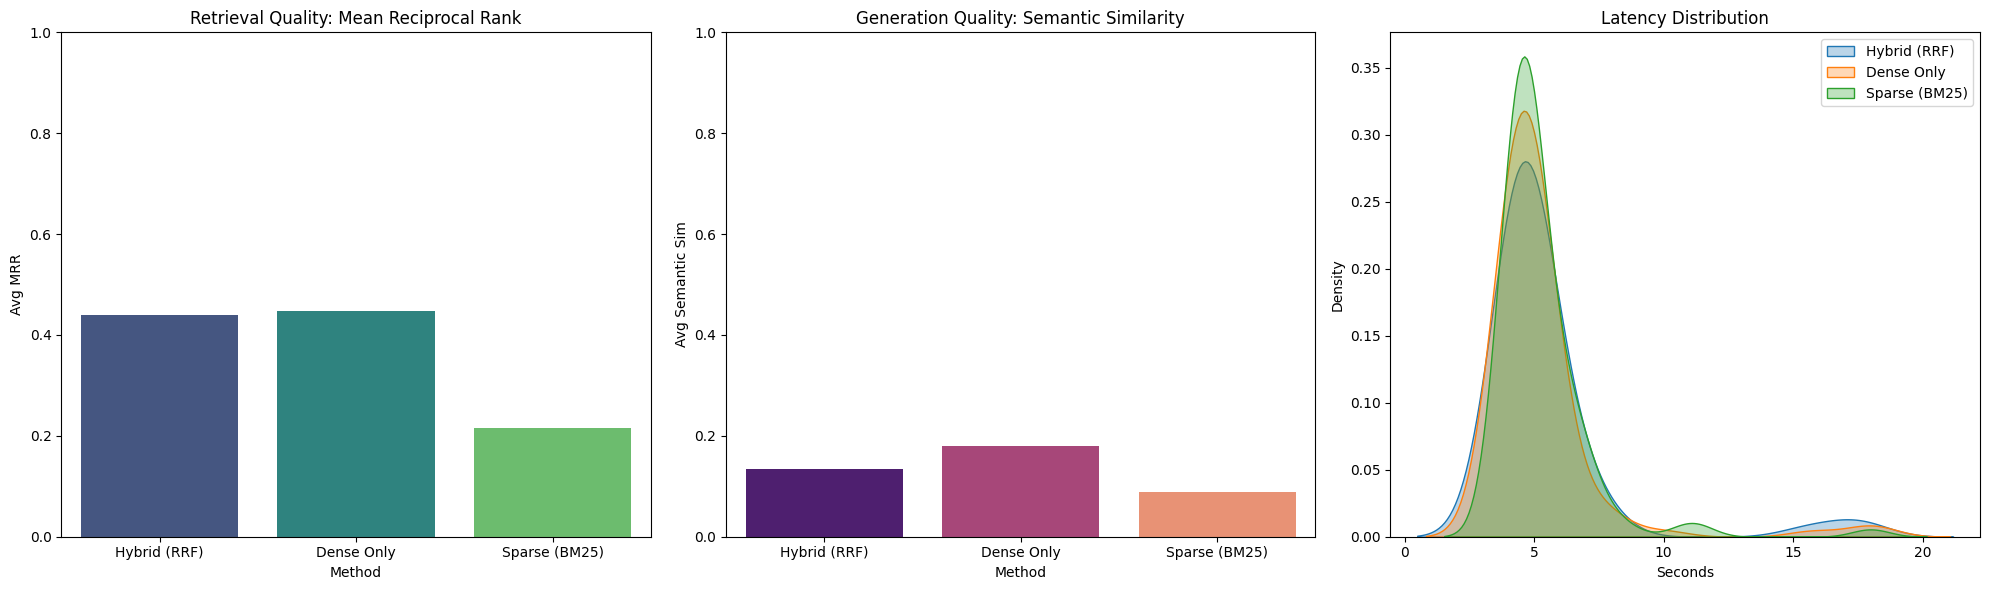


### 🛡️ Adversarial Robustness Analysis ###
| Condition         |   Hit Rate |   Sim Score |
|:------------------|-----------:|------------:|
| Baseline (Normal) |       0.54 |    0.134746 |
| Noise (Typos)     |       0.46 |    0.145171 |
| Negation (Logic)  |       0.53 |    0.155363 |


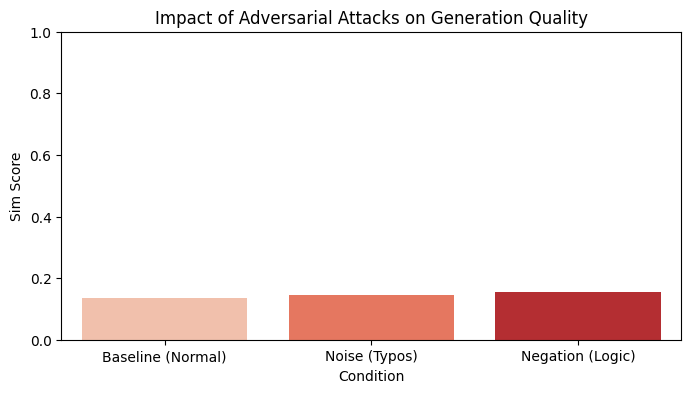


### ⚠️ Error Analysis (Hybrid (RRF) Failures) ###
🔴 Question: Of interest lies how these words relate?:a Almost like someone had gone wild looking around this site the writer wrote down about being scared when you enter another'e institution by the sign
   Ground Truth URL: https://en.wikipedia.org/wiki/Newnham_College,_Cambridge
   Generated Answer: The Cabin in the Woods is an astonishing meta-feat , capable of being funny , strange , and scary—frequently all at the same time .
------------------------------------------------------------
🔴 Question: While in television actress Jane'd on Ellen in 1992 to which comedian is Randie Whitestein best seller she directed o g in 1998 her book of what made Fins movies her only child actress until 1994 to later see through them the whole catalog of movies and serial theatre plays?: --. Yes It would
   Ground Truth URL: https://en.wikipedia.org/wiki/Karen_Finley
   Generated Answer: NCIS
---------------------------------------------------------

In [ ]:
dfs_dict = {
    'Hybrid (RRF)': df_hybrid,
    'Dense Only': df_dense,
    'Sparse (BM25)': df_sparse
}

# Run the report passing the adversarial dataframes
final_report = generate_report(dfs_dict, df_adv_noise=df_adv_noise, df_adv_neg=df_adv_neg)

# Save results
df_hybrid.to_csv("hybrid_rag_evaluation_results.csv", index=False)